<a href="https://colab.research.google.com/github/martynalacha/Computational-Intelligence-Labs/blob/main/multilayer_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Neural Network Performance in Medical Data Classification

The following section implements a classification pipeline to predict drug efficacy based on two chemical components found in blood samples. The analysis focuses on the impact of network depth and layer density on the model's ability to form correct decision boundaries.

Key implementation steps:

* **Data Preparation:** Loading medicine.txt and performing feature scaling to handle non-normalized input values.

* **Stratified Splitting:** Partitioning the data into training and testing sets (80/20 ratio) while preserving class balance.

* **Architectural Exploration:** Defining and training 5 to 8 different MLP structures to compare their performance.

* **Visualization of Decision Boundaries:** Plotting how different networks (from high-performing to underfitted/overfitted ones) partition the feature space.

* **Comparative Analysis:** Selecting the optimal architecture based on classification accuracy and generalization capabilities.

Dataset loaded successfully.
   Presence 1  Presence 2  Was medicine effective?
0     0.04609     6010.05                        0
1     0.02237     6119.66                        0
2     0.05054     7037.36                        0
3     0.03155     5009.20                        0
4     0.02256     6214.69                        0

Dataset size before outlier removal: (1350, 3)
Dataset size after outlier removal: (1285, 3)
Class distribution check: (np.float64(542.0), np.float64(743.0))


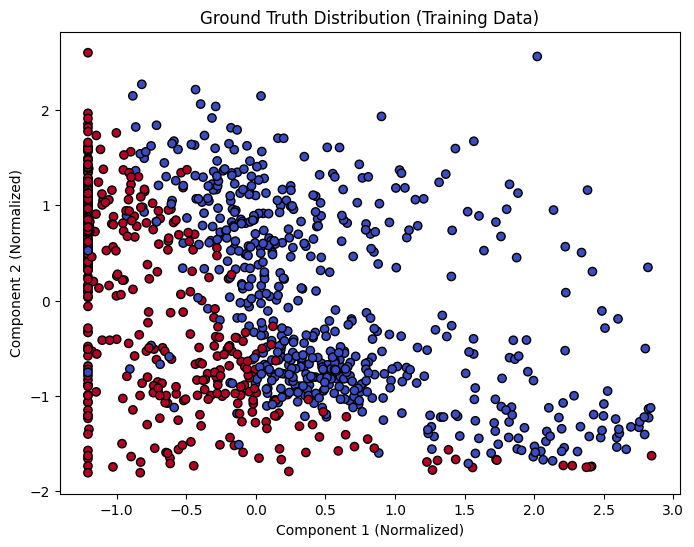

Network Architecture: ()
Training Accuracy: 0.9105
Test Accuracy: 0.8833


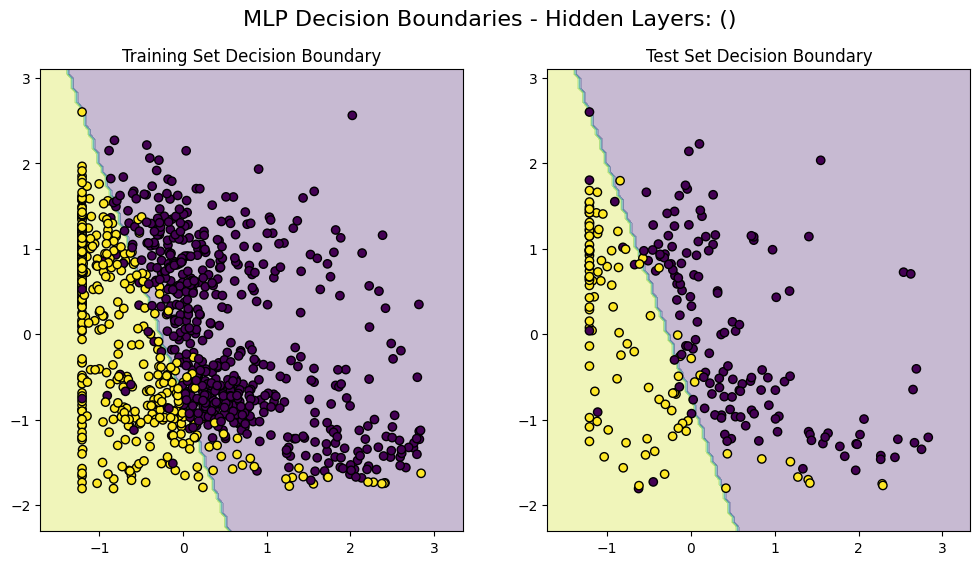

Network Architecture: (4,)
Training Accuracy: 0.9095
Test Accuracy: 0.8794


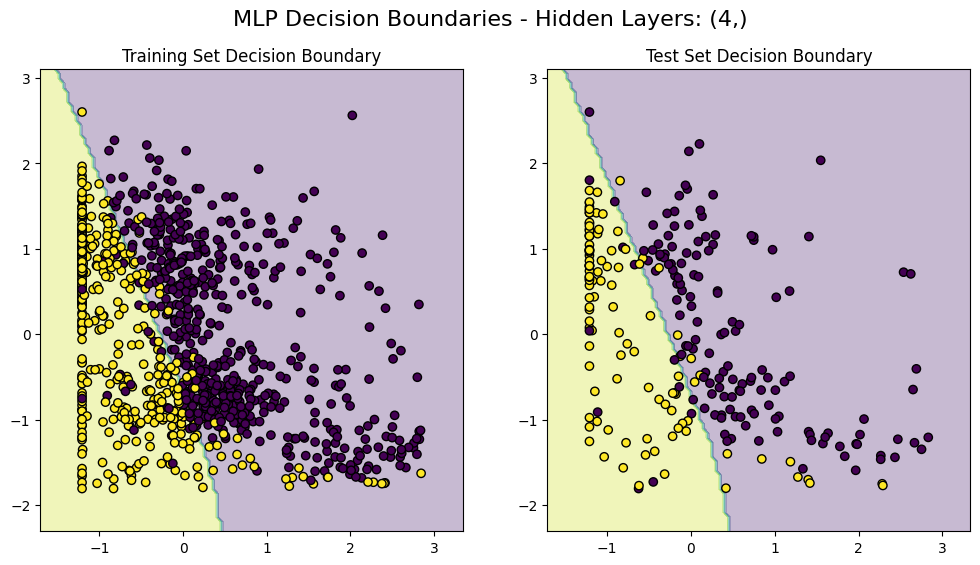

Network Architecture: (20,)
Training Accuracy: 0.9173
Test Accuracy: 0.9066


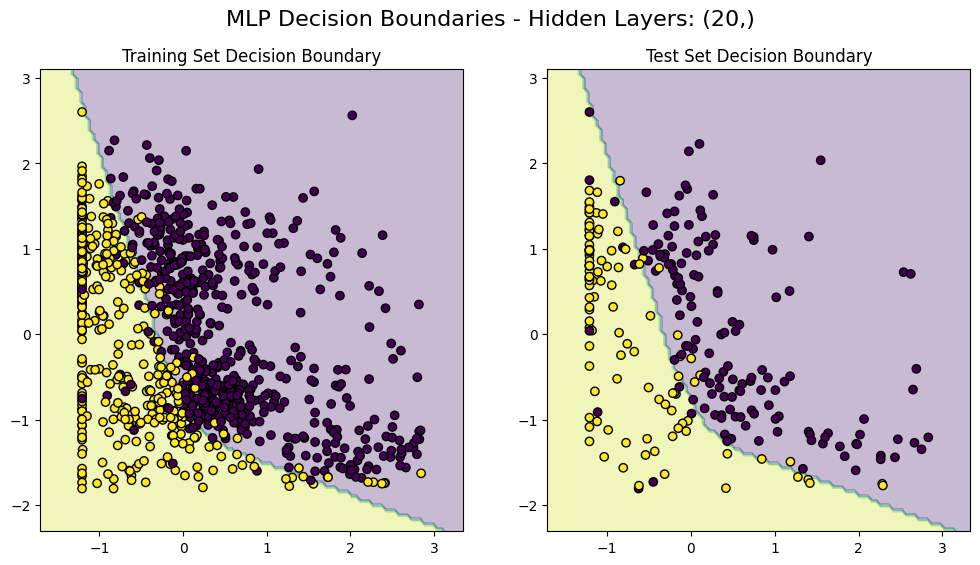

Network Architecture: (5, 5, 5)
Training Accuracy: 0.9105
Test Accuracy: 0.9027


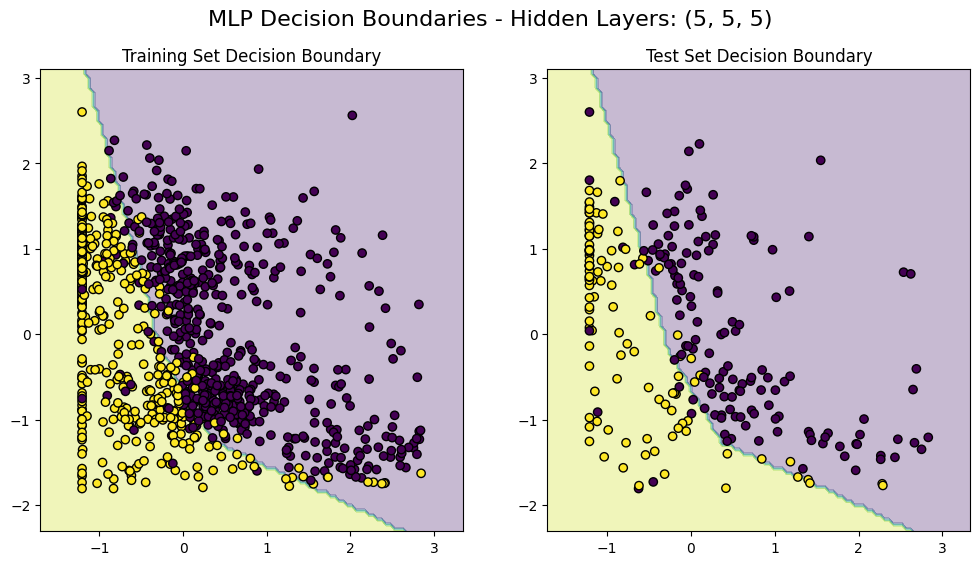

Network Architecture: (16, 8, 4)
Training Accuracy: 0.9173
Test Accuracy: 0.8872


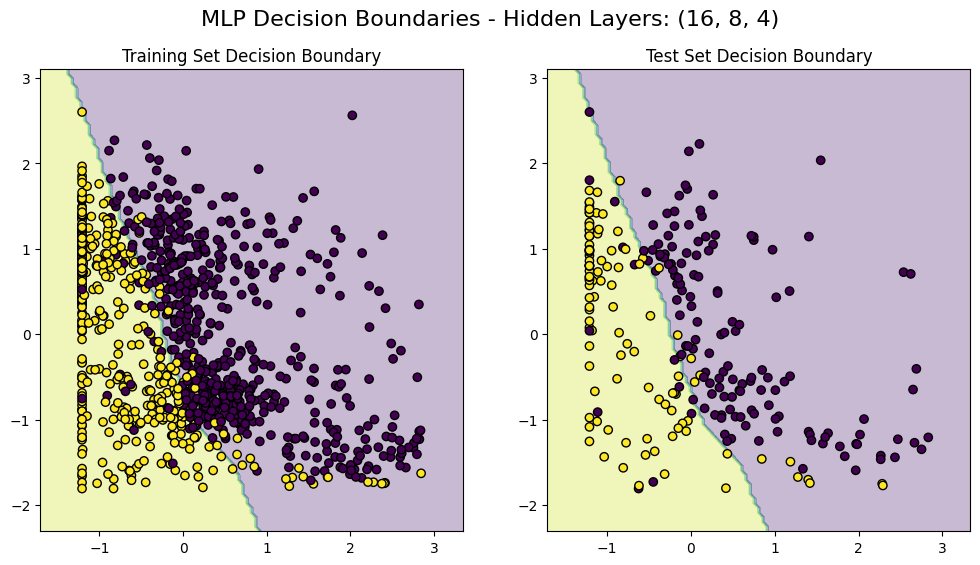

Network Architecture: (4, 16, 4)
Training Accuracy: 0.9261
Test Accuracy: 0.8988


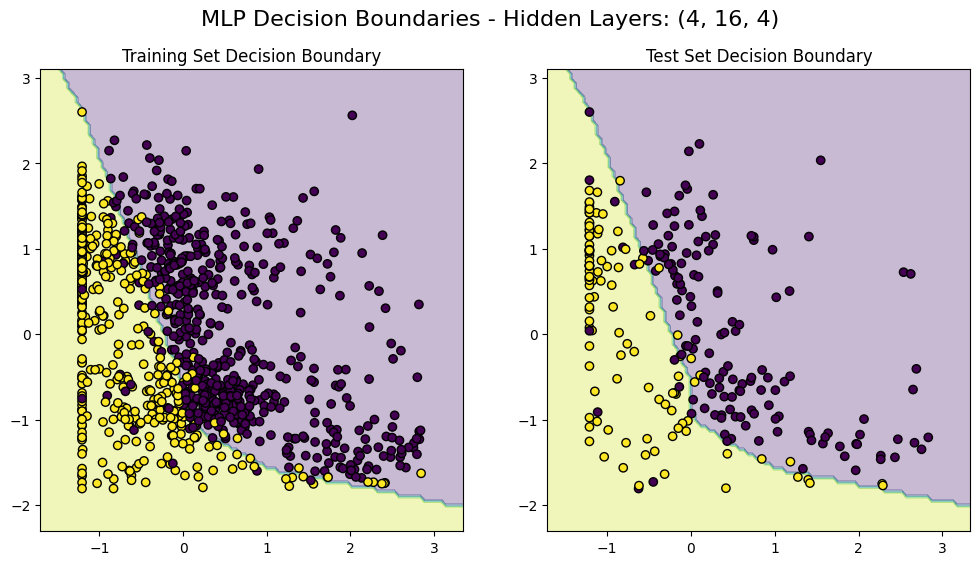

Network Architecture: (100, 100)
Training Accuracy: 0.9241
Test Accuracy: 0.9066


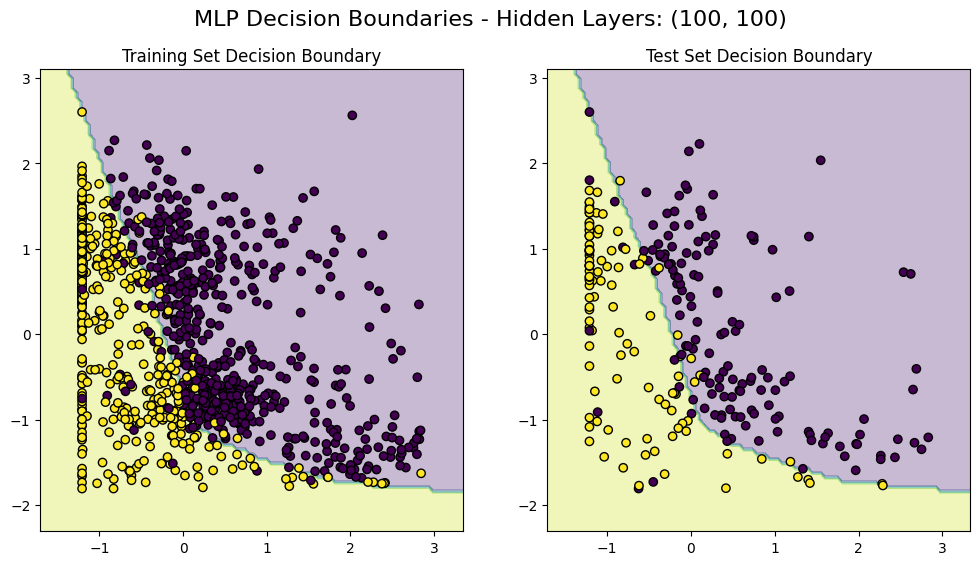

Network Architecture: (10, 10, 10, 10, 10, 10)
Training Accuracy: 0.9270
Test Accuracy: 0.9066


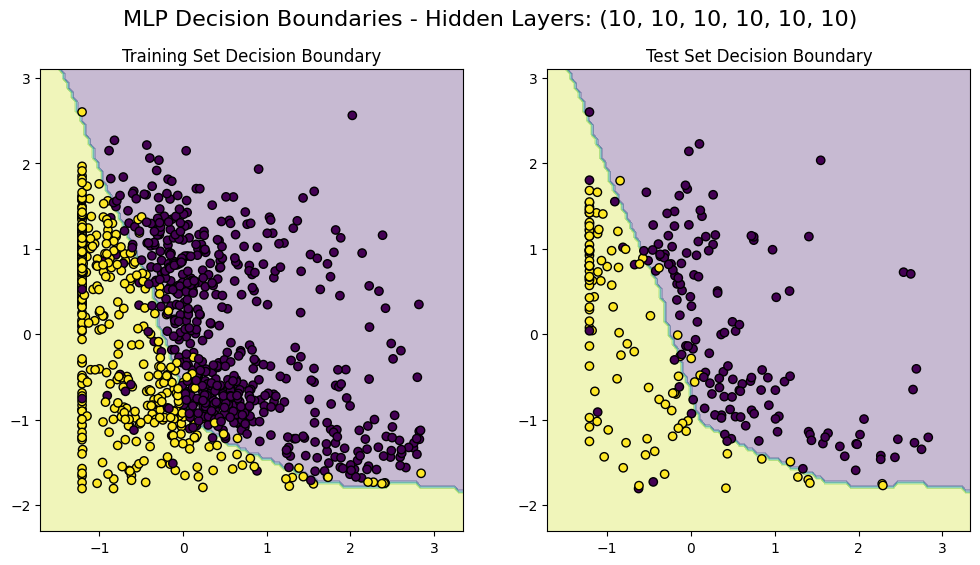

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
file_path = '/content/sample_data/medicine.txt'

try:
    # Loading the dataset from the specified file
    df = pd.read_csv(file_path, sep=',')
    print("Dataset loaded successfully.")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File '{file_path}' not found.")
except Exception as e:
    print(f"Error: {e}")

# Convert dataframe to numpy array for processing
dataset = np.array(df)
# print(dataset)

# Outlier removal using the Interquartile Range (IQR) method
print(f"\nDataset size before outlier removal: {dataset.shape}")

Q1 = np.percentile(dataset[:, : 2], 25, axis = 0)
Q3 = np.percentile(dataset[:, : 2], 75, axis = 0)
IQR = Q3 - Q1

# Calculate lower and upper bounds for filtering
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create a mask for rows containing outliers in any feature
outliers_mask = (dataset[:, : 2] < lower_bound) | (dataset[:, : 2] > upper_bound)
rows_with_outliers = np.any(outliers_mask, axis=1)

dataset = dataset[~rows_with_outliers]
print(f"Dataset size after outlier removal: {dataset.shape}")

# Separate features (X) and target labels (y)
X, y = dataset[:, : 2], dataset[: , 2]

print(f"Class distribution check: {y.sum(), y.shape[0] - y.sum()}")

# Split the dataset into training and testing sets (80/20 ratio)
# 'stratify=y' ensures that both sets have the same class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Feature standardization (Z-score normalization)
# Crucial for MLP convergence and ensuring features are on the same scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Visualization of the Ground Truth distribution
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.title("Ground Truth Distribution (Training Data)")
plt.xlabel("Component 1 (Normalized)")
plt.ylabel("Component 2 (Normalized)")
plt.show()

# Define various network architectures to test performance and decision complexity
hidden_layer_sizes = [
    (),                       # No hidden layers (equivalent to Logistic Regression)
    (4,),                     # Minimal single-layer network
    (20,),                    # Wide single-layer network
    (5, 5, 5),                # Multiple narrow layers
    (16, 8, 4),               # Funnel structure (gradual reduction of complexity)
    (4, 16, 4),               # Diamond structure (expansion then reduction)
    (100, 100),               # Over-parameterized (high risk of overfitting)
    (10, 10, 10, 10, 10, 10)  # Very deep architecture (testing for vanishing gradients)
]

# Helper function to visualize the model's decision boundaries
def plot_decision_boundary(model, X, y, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')

# Iterate through each architecture to train and evaluate
for size in hidden_layer_sizes:

  mlp = MLPClassifier(hidden_layer_sizes=size, activation='relu', solver='adam',
                      max_iter=3000, alpha=0.0001, random_state=42)

  # Train the model
  mlp.fit(X_train, y_train)

  # Calculate and display performance metrics
  train_accuracy = accuracy_score(y_train, mlp.predict(X_train))
  test_accuracy = accuracy_score(y_test, mlp.predict(X_test))
  print(f"Network Architecture: {size}")
  print(f"Training Accuracy: {train_accuracy:.4f}")
  print(f"Test Accuracy: {test_accuracy:.4f}")

  fig, ax = plt.subplots(1, 2, figsize=(12, 6))
  fig.suptitle(f"MLP Decision Boundaries - Hidden Layers: {size}", fontsize=16)
  plot_decision_boundary(mlp, X_train, y_train, ax[0])
  ax[0].set_title("Training Set Decision Boundary")

  plot_decision_boundary(mlp, X_test, y_test, ax[1])
  ax[1].set_title("Test Set Decision Boundary")
  plt.show()

#### Results and Comparative Analysis

The table below summarizes the performance of the evaluated architectures:

| Network Architecture | Training Accuracy | Test Accuracy |
| :--- | :---: | :---: |
| **() – Linear Model** | 0.9105 | 0.8833 |
| **(4,)** | 0.9095 | 0.8794 |
| **(20,) – Optimal** | 0.9173 | **0.9066** |
| **(5, 5, 5)** | 0.9105 | 0.9027 |
| **(16, 8, 4)** | 0.9173 | 0.8872 |
| **(4, 16, 4)** | 0.9261 | 0.8988 |
| **(100, 100)** | 0.9241 | 0.9066 |
| **(10, 10, 10, 10, 10, 10)** | **0.9270** | 0.9066 |

#### Key Conclusions:
* **Underfitting in Linear Models:** The linear baseline () fails to capture non-linear relationships, resulting in a straight-line boundary and the lowest accuracy.
* **Optimal Generalization:** The **(20,)** architecture provides the best balance between complexity and performance. It successfully separates clusters without fitting to noise.
* **Overfitting in Deep Models:** While the deep **(10,10,10,10,10,10)** network achieved the highest training accuracy, it produced highly irregular decision boundaries, suggesting it began to "memorize" the training data.

## Classification of Highly Imbalanced Biological Data (Yeast Dataset)

This task involves the classification of protein localization sites using the Yeast dataset from the UCI Machine Learning Repository. The primary challenge lies in the significant class imbalance within the dataset.

Key implementation steps:
* **Exploratory Data Analysis (EDA):** An initial analysis of the dataset will be performed to understand feature distributions and the extent of class imbalance.

* **Model Optimization:** Different network hyperparameters will be tuned to achieve the highest possible classification performance despite the uneven distribution of samples.

* **Comprehensive Metrics:** Performance will be evaluated using a confusion matrix for both training and testing sets. In addition to accuracy, metrics such as precision, recall, and F1-score will be calculated to provide a deeper understanding of model behavior.

* **Critical Assessment:** The analysis will address whether an accuracy of 0.5 is an acceptable result for this specific imbalanced dataset.

* **Computational Efficiency:** The training time (fit function execution) will be measured and compared across different network architectures.

<>:123: SyntaxWarning: invalid escape sequence '\D'
<>:123: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_9270/2393876223.py:123: SyntaxWarning: invalid escape sequence '\D'
  print(f"\Detailed Classification Report (Test Set):")


Initial Data Snapshot:
     Seq Name   mcg   gvh   alm   mit  erl  pox   vac   nuc    y
0  ADT1_YEAST  0.58  0.61  0.47  0.13  0.5  0.0  0.48  0.22  MIT
1  ADT2_YEAST  0.43  0.67  0.48  0.27  0.5  0.0  0.53  0.22  MIT
2  ADT3_YEAST  0.64  0.62  0.49  0.15  0.5  0.0  0.53  0.22  MIT
3  AAR2_YEAST  0.58  0.44  0.57  0.13  0.5  0.0  0.54  0.22  NUC
4  AATM_YEAST  0.42  0.44  0.48  0.54  0.5  0.0  0.48  0.22  MIT

Total elements: 14840
Dataset shape: (1484, 10)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Seq Name  1484 non-null   object 
 1   mcg       1484 non-null   float64
 2   gvh       1484 non-null   float64
 3   alm       1484 non-null   float64
 4   mit       1484 non-null   float64
 5   erl       1484 non-null   float64
 6   pox       1484 non-null   float64
 7   vac       1484 non-null   float64
 8   nuc       1484

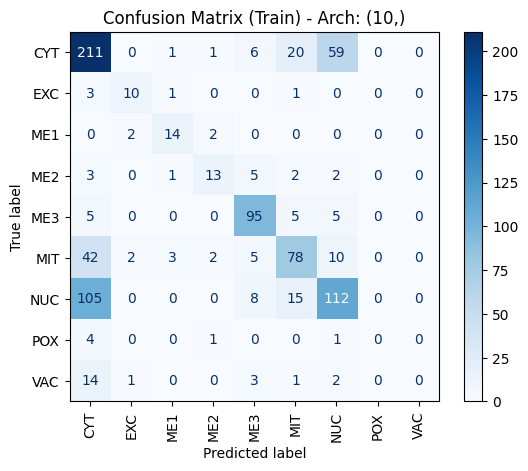



[Test Set Metrics]
Accuracy: 0.593607305936073
Weighted Precision: 0.57651286988215
Weighted Recall: 0.593607305936073
Weighted F1 Score: 0.5782468711868081

Confusion Matrix (Test)


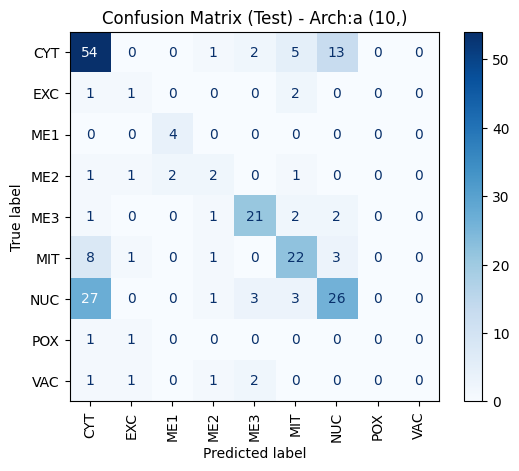

\Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.57      0.72      0.64        75
           1       0.20      0.25      0.22         4
           2       0.67      1.00      0.80         4
           3       0.29      0.29      0.29         7
           4       0.75      0.78      0.76        27
           5       0.63      0.63      0.63        35
           6       0.59      0.43      0.50        60
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         5

    accuracy                           0.59       219
   macro avg       0.41      0.46      0.43       219
weighted avg       0.58      0.59      0.58       219



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



--- Structure: (50, 50) ---
Training time: 3.4451s

[Training Set Metrics]
Accuracy: 0.9166666666666666
Weighted Precision: 0.9181086325778453
Weighted Precision: 0.9166666666666666
Weighted F1 Score: 0.915896760740721

Confusion matrix


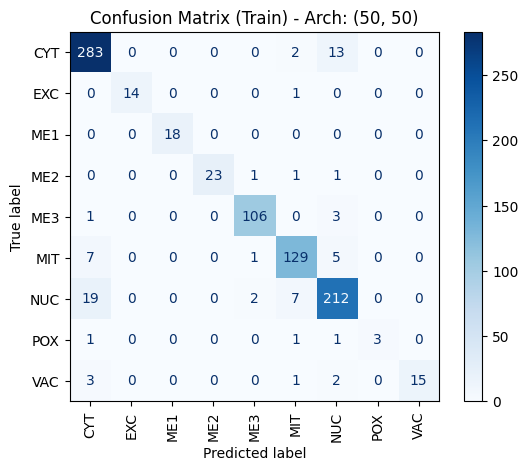



[Test Set Metrics]
Accuracy: 0.5342465753424658
Weighted Precision: 0.5224605717096228
Weighted Recall: 0.5342465753424658
Weighted F1 Score: 0.5255615478475519

Confusion Matrix (Test)


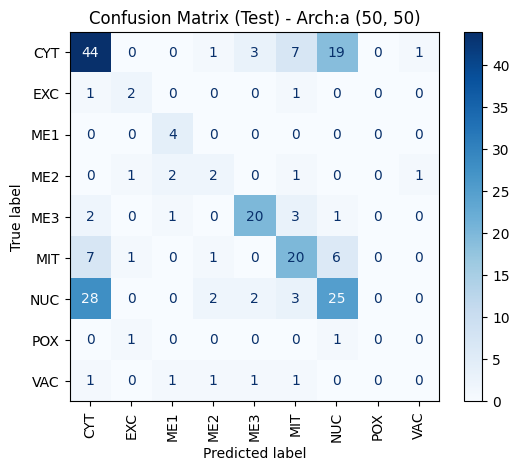

\Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.53      0.59      0.56        75
           1       0.40      0.50      0.44         4
           2       0.50      1.00      0.67         4
           3       0.29      0.29      0.29         7
           4       0.77      0.74      0.75        27
           5       0.56      0.57      0.56        35
           6       0.48      0.42      0.45        60
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         5

    accuracy                           0.53       219
   macro avg       0.39      0.46      0.41       219
weighted avg       0.52      0.53      0.53       219


--- Structure: (100, 50, 25) ---
Training time: 4.9102s

[Training Set Metrics]
Accuracy: 1.0
Weighted Precision: 1.0
Weighted Precision: 1.0
Weighted F1 Score: 1.0

Confusion matrix


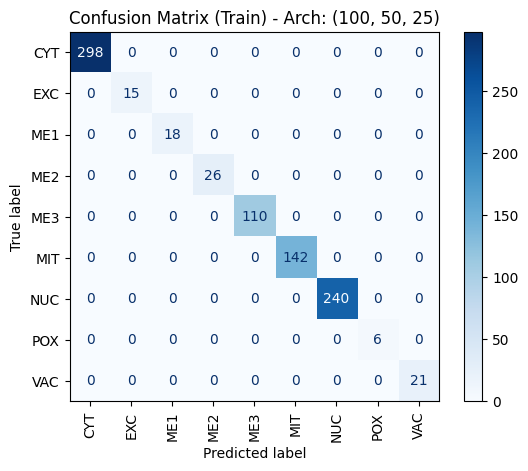



[Test Set Metrics]
Accuracy: 0.5068493150684932
Weighted Precision: 0.49404647020780296
Weighted Recall: 0.5068493150684932
Weighted F1 Score: 0.49789782643111263

Confusion Matrix (Test)


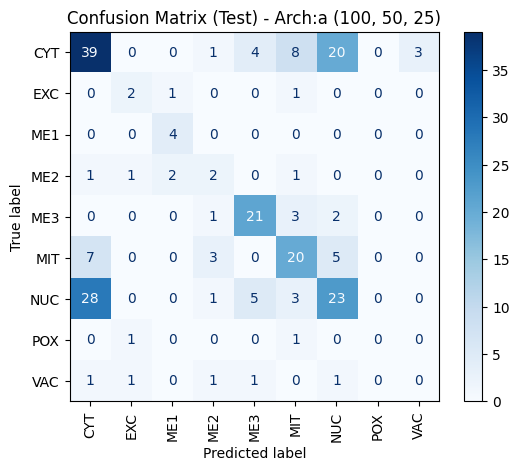

\Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.51      0.52      0.52        75
           1       0.40      0.50      0.44         4
           2       0.57      1.00      0.73         4
           3       0.22      0.29      0.25         7
           4       0.68      0.78      0.72        27
           5       0.54      0.57      0.56        35
           6       0.45      0.38      0.41        60
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         5

    accuracy                           0.51       219
   macro avg       0.38      0.45      0.40       219
weighted avg       0.49      0.51      0.50       219


--- Structure: (16, 16, 16, 16) ---
Training time: 3.0232s

[Training Set Metrics]
Accuracy: 0.8139269406392694
Weighted Precision: 0.8097462243308412
Weighted Precision: 0.8139269406392694
Weighted F1 Score: 0.8103874005615024

Confusion matrix


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


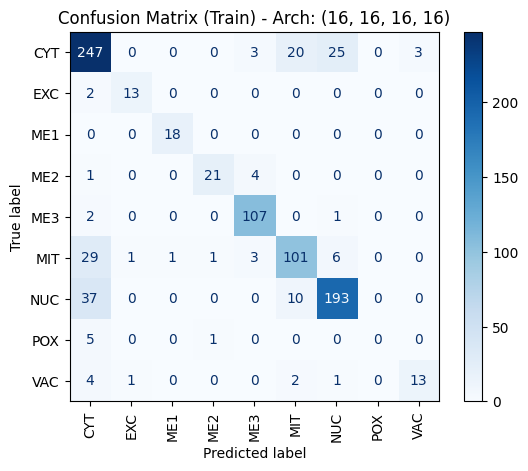



[Test Set Metrics]
Accuracy: 0.5159817351598174
Weighted Precision: 0.5143490143129653
Weighted Recall: 0.5159817351598174
Weighted F1 Score: 0.5143751116381097

Confusion Matrix (Test)


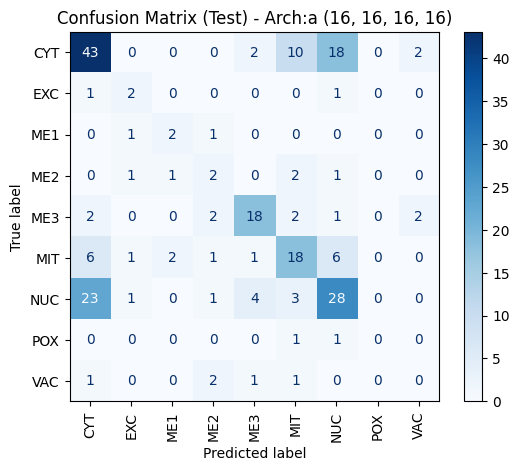

\Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.57      0.57      0.57        75
           1       0.33      0.50      0.40         4
           2       0.40      0.50      0.44         4
           3       0.22      0.29      0.25         7
           4       0.69      0.67      0.68        27
           5       0.49      0.51      0.50        35
           6       0.50      0.47      0.48        60
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         5

    accuracy                           0.52       219
   macro avg       0.36      0.39      0.37       219
weighted avg       0.51      0.52      0.51       219



In [3]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import time
from sklearn.metrics import  precision_score, recall_score, f1_score, classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


# Define feature names and load the Yeast dataset
cols = ['Seq Name', 'mcg', 'gvh', 'alm', 'mit', 'erl', 'pox', 'vac', 'nuc', 'y']
df_yeast = pd.read_csv('/content/sample_data/yeast.data', sep=r'\s+', names=cols, header=None)

# Initial data inspection: dimensions, types, and class distribution
print("Initial Data Snapshot:")
print(df_yeast.head())
print(f"\nTotal elements: {df_yeast.size}")
print(f"Dataset shape: {df_yeast.shape}")
print(f"\nDataset Information:")
df_yeast.info()
print(f"\nunique Classes: {df_yeast['y'].unique()}")
print(f"Class counts: {df_yeast['y'].value_counts()}")


# Data Cleaning: Remove duplicates and non-predictive features
print(f"Number of duplicates: {df_yeast.duplicated().sum()}")

df_yeast = df_yeast[~df_yeast.duplicated()]
df_yeast = df_yeast.drop('Seq Name', axis=1)

np_yeast = np.array(df_yeast)

# Outlier Detection using the Interquartile Range (IQR) method per feature
Q1 = np.percentile(np_yeast[:, : -1], 25, axis=0)
Q3 = np.percentile(np_yeast[:, : -1], 75, axis=0)
IQR = Q3 - Q1


lower_range = Q1 - 1.5 * IQR
upper_range = Q3 + 1.5 * IQR
features = np_yeast[:, : -1]
outliers_mask = (features < lower_range) | (features > upper_range)
np_yeast = np_yeast[~outliers_mask.any(axis=1)]

# Feature/Target separation and Label Encoding
X = np_yeast[:, : -1]
le = LabelEncoder()
y = le.fit_transform(np_yeast[:, -1])

# Stratified split to ensure minority classes are represented in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Conversion to float and Feature Scaling
# Standardization is essential for MLP convergence with Adam/SGD solvers
X_train = X_train.astype(float)
X_test = X_test.astype(float)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define architectures to evaluate depth vs. width trade-offs
architectures = [
    (10,),
    (50,50),
    (100, 50, 25),
    (16, 16, 16, 16)
]

for struct in architectures:
  # Initialize MLP with an increased iteration limit for convergence
  mlp = MLPClassifier(hidden_layer_sizes=struct, max_iter=1000, random_state=42)

  # Benchmark training time (Efficiency Analysis)
  start = time.time()
  mlp.fit(X_train, y_train)
  end = time.time()

  training_time = end - start
  y_pred_train = mlp.predict(X_train)
  y_pred_test = mlp.predict(X_test)

  print(f"\n--- Structure: {struct} ---")
  print(f"Training time: {training_time:.4f}s")


  # Evaluation on Training Set
  # Using 'weighted' average to account for class imbalance
  print(f"\n[Training Set Metrics]")
  print(f"Accuracy: {accuracy_score(y_train, y_pred_train)}")
  print(f"Weighted Precision: {precision_score(y_train, y_pred_train, average='weighted', zero_division=0)}")
  print(f"Weighted Precision: {recall_score(y_train, y_pred_train, average='weighted', zero_division=0)}")
  print(f"Weighted F1 Score: {f1_score(y_train, y_pred_train, average='weighted', zero_division=0)}")
  print("\nConfusion matrix")

  # Plot Confusion Matrix for Training Set
  matrix_train = confusion_matrix(y_train, y_pred_train)
  disp_train = ConfusionMatrixDisplay(confusion_matrix=matrix_train, display_labels=le.classes_)
  disp_train.plot(cmap='Blues', xticks_rotation='vertical')
  plt.title(f"Confusion Matrix (Train) - Arch: {struct}")
  plt.show()

  # Evaluation on Test Set (Generalization Performance)
  print(f"\n\n[Test Set Metrics]")
  print(f"Accuracy: {accuracy_score(y_test, y_pred_test)}")
  print(f"Weighted Precision: {precision_score(y_test, y_pred_test, average='weighted', zero_division=0)}")
  print(f"Weighted Recall: {recall_score(y_test, y_pred_test, average='weighted', zero_division=0)}")
  print(f"Weighted F1 Score: {f1_score(y_test, y_pred_test, average='weighted', zero_division=0)}")
  print("\nConfusion Matrix (Test)")

  # Plot Confusion Matrix for Test Set
  matrix_test = confusion_matrix(y_test, y_pred_test)
  disp = ConfusionMatrixDisplay(confusion_matrix=matrix_test, display_labels=le.classes_)
  disp.plot(cmap='Blues', xticks_rotation='vertical')
  plt.title(f"Confusion Matrix (Test) - Arch:a {struct}")
  plt.show()

  # Detailed Classification Report for individual class performance
  print(f"\Detailed Classification Report (Test Set):")
  print(classification_report(y_test, y_pred_test, zero_division=0))



### Task 2: Performance Summary

| Architecture | Time [s] | Train Acc | Test Acc | Precision* | Recall* | F1-Score* |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **(10,)** | **3.31s** | 0.61 | **0.59** | **0.58** | **0.59** | **0.58** |
| **(50, 50)** | 5.21s | 0.92 | 0.53 | 0.52 | 0.53 | 0.53 |
| **(100, 50, 25)** | 11.35s | 1.00 | 0.51 | 0.49 | 0.51 | 0.50 |
| **(16, 16, 16, 16)** | 6.16s | 0.81 | 0.52 | 0.51 | 0.52 | 0.51 |

*\*Weighted metrics applied due to class imbalance.*

**Conclusions:**
* **Best Model:** The simplest architecture **(10,)** is the most effective. It achieved the highest test metrics with the lowest computational overhead.
* **Overfitting:** Deeper networks (e.g., 100, 50, 25) achieved 100% training accuracy but performed worse on the test set, indicating they memorized noise rather than general patterns.
* **Data Limits:** Minority classes (POX, VAC) remained undetected regardless of model depth, confirming that architecture cannot compensate for a lack of representative data.
* **Feature Similarity:** Persistent confusion between **NUC** and **CYT** classes suggests high feature overlap, setting a performance ceiling for standard MLP models.
* **Final Verdict:** An accuracy of **~0.60** is a solid result for this specific dataset, significantly exceeding random baseline performance.